Donghang Zou's UChicago ADS Code Sample

This is an excerpt from a larger project: https://github.com/Booth-DH/Global_AI_Internship

County social conditions help identify where chronic disease and unmet needs coincide. The project uses five CDC PLACES releases from 2021 to 2025 and CDC SVI 2020 and 2022. It cleans and stacks releases into a county panel, correlates social and behavioral factors with diabetes and hypertension, groups counties with K-means, and maps descriptive profiles. This excerpt rebuilds the latest snapshot from raw CSVs. Food, housing, and transportation insecurity are the strongest diabetes correlates, with r of 0.937, 0.921, and 0.914.

In [1]:
# GitHub: https://github.com/Booth-DH/Global_AI_Internship
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch, Patch
from matplotlib.path import Path as MplPath
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

ROOT = Path.cwd() if Path('raw_data').is_dir() else Path.cwd().parent
OUT = ROOT / 'code_sample'
outcomes = ['DIABETES', 'BPHIGH']
factors = ('LPA OBESITY CSMOKING ACCESS2 DEPRESSION SLEEP BINGE RPL_THEMES '
           'RPL_THEME1 RPL_THEME2 RPL_THEME3 RPL_THEME4 FOODINSECU '
           'HOUSINSECU LACKTRPT LONELINESS').split()
svi_cols = [f for f in factors if f.startswith('RPL')]

These functions render the paired correlation bars and county polygons used below.

In [2]:
LABELS = dict(zip(factors, [
    'Physical inactivity', 'Obesity', 'Current smoking', 'No health insurance',
    'Depression', 'Short sleep', 'Binge drinking', 'Overall SVI',
    'SVI: socioeconomic', 'SVI: household', 'SVI: minority status',
    'SVI: housing/transport', 'Food insecurity', 'Housing insecurity',
    'Transportation barriers', 'Loneliness']))

def plot_correlations(r):
    ranked = r.sort_values('DIABETES', ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.15))
    for ax, start in zip(axes, [0, 8]):
        values = ranked.iloc[start:start + 8]
        y = np.arange(len(values))
        ax.barh(y - 0.18, values.DIABETES, height=0.34, color='#176b87', label='Diabetes')
        ax.barh(y + 0.18, values.BPHIGH, height=0.34, color='#cd743b', label='Hypertension')
        ax.set_yticks(y, [LABELS[f] for f in values.index], fontsize=11)
        ax.set(xlim=(-1, 1), xticks=[-1, 0, 1], xlabel='Pearson r')
        ax.invert_yaxis()
        ax.axvline(0, color='#777777', linewidth=0.6)
        ax.spines[['top', 'right']].set_visible(False)
    fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center',
               ncol=2, frameon=False, fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.9), w_pad=1.8)
    fig.savefig(OUT / 'fig_correlations.png', dpi=240, bbox_inches='tight')
    return fig

def plot_county_profiles(complete):
    tiers = list(complete.tier.cat.categories)
    colors = dict(zip(tiers, ['#27ae60', '#f39c12', '#e67e22', '#c0392b']))
    missing = 'Not clustered (measures unavailable)'
    lookup = complete.tier.astype('string').map(colors).to_dict()
    geo = json.loads((ROOT / 'processed_data/us_counties.geojson').read_text())
    fig, ax = plt.subplots(figsize=(8, 3.6))
    for county in geo['features']:
        fips, geometry = county['id'], county['geometry']
        if fips[:2] in {'02', '15', '72'}:
            continue
        polygons = geometry['coordinates']
        if geometry['type'] == 'Polygon':
            polygons = [polygons]
        for polygon in polygons:
            # Preserve holes as well as disconnected county polygons.
            rings = [MplPath(ring, closed=True) for ring in polygon]
            outline = MplPath.make_compound_path(*rings)
            patch = PathPatch(outline, facecolor=lookup.get(fips, '#d3d3d3'),
                              edgecolor='white', linewidth=0.12)
            ax.add_patch(patch)
    ax.set(xlim=(-125, -66), ylim=(24, 50), aspect=1.25,
           title='County profiles in the contiguous United States')
    ax.axis('off')
    colors[missing] = '#d3d3d3'
    legend = [Patch(color=color, label=tier) for tier, color in colors.items()]
    ax.legend(handles=legend, loc='upper center', bbox_to_anchor=(0.5, -0.01),
              ncol=3, fontsize=12, frameon=False)
    fig.savefig(OUT / 'fig_risk_tier_map.png', dpi=240, bbox_inches='tight')
    return fig

The latest snapshot combines PLACES 2025 with SVI 2022.

In [3]:
# String identifiers preserve leading zeros in county FIPS codes.
places = pd.read_csv(ROOT / 'raw_data/places_county_2025.csv', low_memory=False,
    dtype={'locationid': 'string', 'year': 'int16', 'data_value': 'float64'})
svi = pd.read_csv(ROOT / 'raw_data/svi_county_2022.csv', dtype={'FIPS': 'string'},
                  usecols=['FIPS', *svi_cols])
print(f'locationid: {places.locationid.dtype}; FIPS: {svi.FIPS.dtype}; '
      f'data_value: {places.data_value.dtype}')

locationid: string; FIPS: string; data_value: float64


Age-adjusted estimates form one row per county.

In [4]:
def prepare_county_snapshot(places, svi):
    health = places.loc[(places.stateabbr != 'US') &
                       (places.data_value_type == 'Age-adjusted prevalence')].copy()
    health['FIPS'] = health.locationid.str.zfill(5)
    health = health.sort_values('year').drop_duplicates(['FIPS', 'measureid'], keep='last')
    wide = health.pivot(index='FIPS', columns='measureid', values='data_value')
    # SVI -999 is missing; a one-to-one join prevents duplicate county weights.
    svi = svi.assign(FIPS=svi.FIPS.str.zfill(5)).replace(-999, np.nan).set_index('FIPS')
    return wide.join(svi, how='inner', validate='one_to_one').dropna(
        subset=[*outcomes, 'RPL_THEMES'])

counties = prepare_county_snapshot(places, svi)

The function returns Pearson r and the county count for each factor.

In [5]:
def compare_correlations(data, outcome, factors, sample_policy='pairwise'):
    assert sample_policy in {'pairwise', 'common'}
    values = data[[outcome, *factors]]
    # Common holds geography fixed; pairwise keeps all available pairs.
    if sample_policy == 'common':
        values = values.dropna()
    rows = []
    for factor in factors:
        pairs = values[[outcome, factor]].dropna()
        rows.append((factor, pairs[factor].corr(pairs[outcome]), len(pairs)))
    return pd.DataFrame(rows, columns=['factor', 'r', 'n']).set_index('factor')

The bars rank all 16 factors by diabetes r; the table compares four factors, with common_r and common_n for diabetes.

            DIABETES  BPHIGH     n  common_r  common_n
FOODINSECU     0.937   0.838  2299     0.937      2299
HOUSINSECU     0.921   0.816  2299     0.921      2299
LACKTRPT       0.914   0.816  2299     0.914      2299
LPA            0.873   0.810  2956     0.850      2299


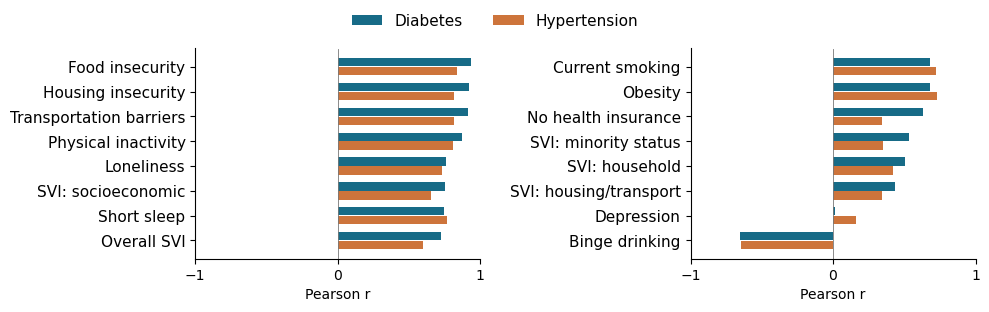

In [6]:
results = {y: compare_correlations(counties, y, factors) for y in outcomes}
r = pd.DataFrame({y: result.r for y, result in results.items()})
shown = ['FOODINSECU', 'HOUSINSECU', 'LACKTRPT', 'LPA']
common = compare_correlations(counties, 'DIABETES', shown, sample_policy='common')
paired = r.loc[shown].join(results['DIABETES'].n)
common = common.rename(columns={'r': 'common_r', 'n': 'common_n'})
comparison = paired.join(common)
print(comparison.round(3).rename_axis(None).to_string())
comparison.to_csv(OUT / 'correlation_summary.csv')
plot_correlations(r)
plt.show()

Factors with mean absolute r of at least 0.40 join both outcomes; the table reports unweighted county means (% and SVI rank).

16 features; 2,299/2,956 counties; silhouette = 0.203
          counties  diabetes  hypertension    SVI
Low            765     9.090        29.758  0.190
Moderate       788    10.765        33.306  0.456
High           508    12.555        36.755  0.754
Highest        238    15.786        42.943  0.895


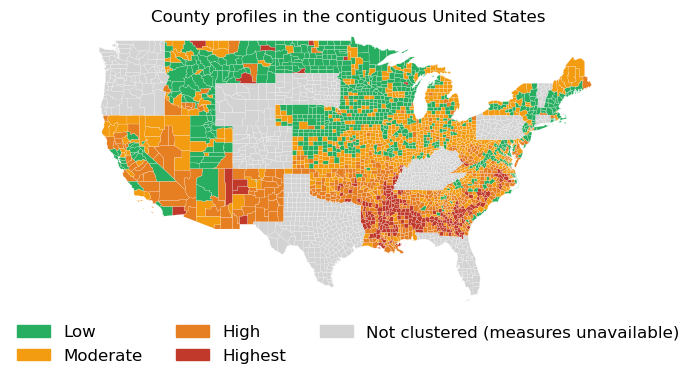

In [7]:
strength = r.abs().mean(axis=1).sort_values(ascending=False)
features = outcomes + strength[strength >= 0.40].index.tolist()
complete = counties.dropna(subset=features).copy()
# Standardize before K-means so units do not determine distance.
z = StandardScaler().fit_transform(complete[features])
model = KMeans(n_clusters=4, random_state=42, n_init=10).fit(z)
anchors = [features.index(f) for f in [*outcomes, 'RPL_THEMES']]
order = np.argsort(model.cluster_centers_[:, anchors].mean(axis=1))
tiers = ['Low', 'Moderate', 'High', 'Highest']
labels = pd.Series(model.labels_, index=complete.index)
ordered_labels = labels.map(dict(zip(order, tiers)))
complete['tier'] = pd.Categorical(ordered_labels, categories=tiers, ordered=True)
summary = complete.groupby('tier', observed=True).agg(counties=('DIABETES', 'size'),
    diabetes=('DIABETES', 'mean'), hypertension=('BPHIGH', 'mean'), SVI=('RPL_THEMES', 'mean'))
print(f'{len(features)} features; {len(complete):,}/{len(counties):,} counties; '
      f'silhouette = {silhouette_score(z, model.labels_):.3f}')
print(summary.round(3).rename_axis(None).to_string())
summary.to_csv(OUT / 'cluster_summary.csv')
plot_county_profiles(complete)
plt.show()

Grey areas include 657 eligible counties in CO, FL, OR, SD, TN, TX, VT, WA, and WY lacking food, housing, transport, and loneliness measures; KY and PA have only five measures and no diabetes or hypertension estimates. Loving County, TX has suppressed outcomes. Nine CT planning regions lack cached geometry.

The three social-needs associations are stronger than physical inactivity. For inactivity, diabetes r falls from 0.873 on 2,956 counties to 0.850 on the 2,299-county common sample. Higher-burden profiles concentrate in the Deep South. These associations are not causal, measurement years differ (PLACES 2022/2023 and SVI 2022), and the profiles are descriptive and overlapping (silhouette 0.203).